# Directed Graphs and BPMN for MOSFRA / MOWFRA Parts (grouped by PBB_FAMILY)

Loads every CSV file matching `MO*FRA*.csv` in `data/villach/`, groups rows by
`PBB_FAMILY`, and discovers a **directed graph** and **BPMN model** for each group.

- **Case identifier** = `ROUTE` (same role as `ROUTEID` in notebook 04)
- **Event / activity** = `OPERATION`

In [1]:
import pandas as pd
import pm4py
from pathlib import Path

DATA_DIR = Path("../../data/villach")
OUTPUT_DIR = DATA_DIR / "heuristic_nets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fra_files = sorted(DATA_DIR.glob("MO*FRA*.csv"))
fra_files

[WindowsPath('../../data/villach/MOSFRA_DESFRA_DILABL.csv'),
 WindowsPath('../../data/villach/MOSFRA_DESFRA_DIZZZZ.csv'),
 WindowsPath('../../data/villach/MOWFRA_ERRZZZ_DIZZZZ.csv')]

## Read and concatenate all CSVs

In [2]:
frames = []
for f in fra_files:
    first_line = open(f, encoding="utf-8-sig").readline().strip()
    if first_line.startswith("sep="):
        sep = first_line.split("=", 1)[1]
        skip = 1
    else:
        sep = ";" if ";" in first_line else ","
        skip = 0
    df = pd.read_csv(f, sep=sep, dtype=str, skiprows=skip).fillna("")
    df["_source_file"] = f.stem
    frames.append(df)
    print(f"  {f.name}: {len(df)} rows")

raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(raw)} rows from {len(fra_files)} files")
print(f"PBB_FAMILY values: {sorted(raw['PBB_FAMILY'].unique())}")

  MOSFRA_DESFRA_DILABL.csv: 87 rows
  MOSFRA_DESFRA_DIZZZZ.csv: 78 rows
  MOWFRA_ERRZZZ_DIZZZZ.csv: 89 rows

Total: 254 rows from 3 files
PBB_FAMILY values: ['LOGISTICS', 'MOSFRA_DESFRA_DILABL', 'MOSFRA_DESFRA_DIZZZZ', 'MOWFRA_ERRZZZ_DIZZZZ', 'PROCESS_CONTROL_DILABL', 'PROCESS_CONTROL_DIZZZZ']


## Build event logs per PBB_FAMILY

Each `PBB_FAMILY` becomes a separate event log:
- `case:concept:name` = ROUTE
- `concept:name` = OPERATION
- `time:timestamp` = synthetic (same convention as notebook 04)

In [3]:
KEEP_COLS = ["ROUTERELATION", "FACILITY", "ROUTEID", "ROUTE",
             "ROUTEDESCRIPTION", "ROUTEOPERORDER", "OPERATION", "PBB_FAMILY"]

logs = {}
for family, group in raw.groupby("PBB_FAMILY"):
    df = group[KEEP_COLS].drop_duplicates().copy()
    df["ROUTEOPERORDER"] = pd.to_numeric(df["ROUTEOPERORDER"], errors="coerce").fillna(0).astype(int)
    df = df.sort_values(["ROUTE", "ROUTEOPERORDER"]).reset_index(drop=True)

    step_per_route = df.groupby("ROUTE").cumcount()
    df["time:timestamp"] = pd.Timestamp("2024-01-01") + pd.to_timedelta(step_per_route * 2 + 8, unit="h")

    df["case:concept:name"] = df["ROUTE"]
    df["concept:name"] = df["OPERATION"]

    events = df[["case:concept:name", "concept:name", "time:timestamp",
                 "ROUTEOPERORDER", "ROUTERELATION", "FACILITY",
                 "ROUTE", "ROUTEDESCRIPTION"]].copy()

    log = pm4py.convert_to_event_log(events)
    logs[family] = log
    n_routes = df["ROUTE"].nunique()
    print(f"  {family}: {n_routes} routes, {len(events)} events")

  LOGISTICS: 6 routes, 24 events
  MOSFRA_DESFRA_DILABL: 2 routes, 14 events
  MOSFRA_DESFRA_DIZZZZ: 2 routes, 14 events
  MOWFRA_ERRZZZ_DIZZZZ: 2 routes, 12 events
  PROCESS_CONTROL_DILABL: 2 routes, 9 events
  PROCESS_CONTROL_DIZZZZ: 4 routes, 17 events


## Discover and display directed graph and BPMN


  LOGISTICS  (6 traces)


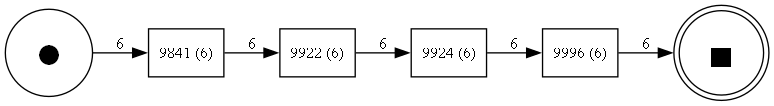

  Directed graph saved to ..\..\data\villach\heuristic_nets\LOGISTICS_dfg.png


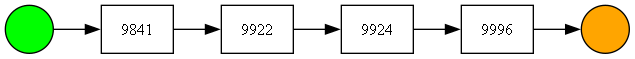

  BPMN saved to ..\..\data\villach\heuristic_nets\LOGISTICS_bpmn.png

  MOSFRA_DESFRA_DILABL  (2 traces)


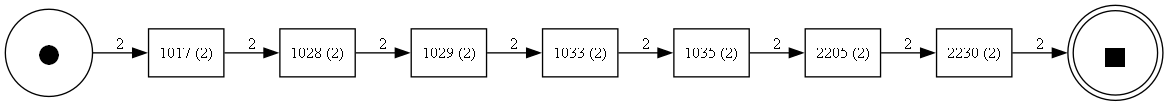

  Directed graph saved to ..\..\data\villach\heuristic_nets\MOSFRA_DESFRA_DILABL_dfg.png


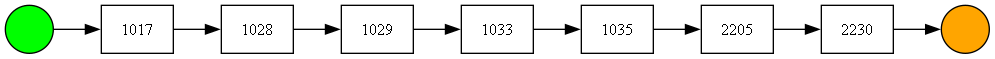

  BPMN saved to ..\..\data\villach\heuristic_nets\MOSFRA_DESFRA_DILABL_bpmn.png

  MOSFRA_DESFRA_DIZZZZ  (2 traces)


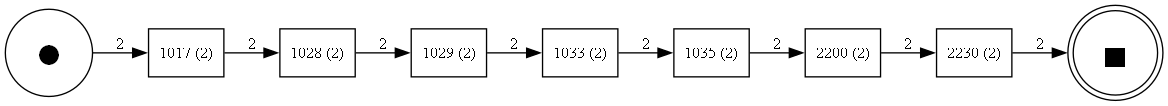

  Directed graph saved to ..\..\data\villach\heuristic_nets\MOSFRA_DESFRA_DIZZZZ_dfg.png


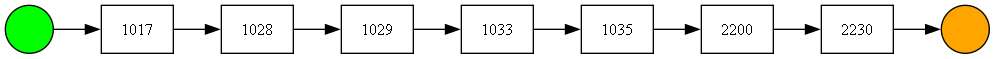

  BPMN saved to ..\..\data\villach\heuristic_nets\MOSFRA_DESFRA_DIZZZZ_bpmn.png

  MOWFRA_ERRZZZ_DIZZZZ  (2 traces)


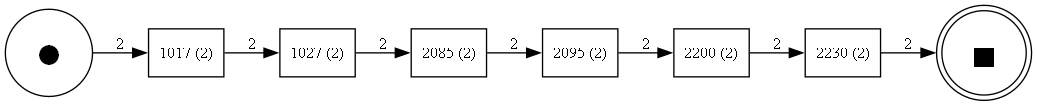

  Directed graph saved to ..\..\data\villach\heuristic_nets\MOWFRA_ERRZZZ_DIZZZZ_dfg.png


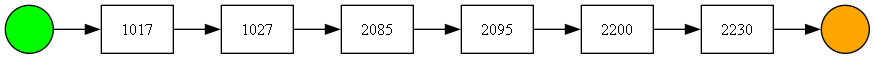

  BPMN saved to ..\..\data\villach\heuristic_nets\MOWFRA_ERRZZZ_DIZZZZ_bpmn.png

  PROCESS_CONTROL_DILABL  (2 traces)


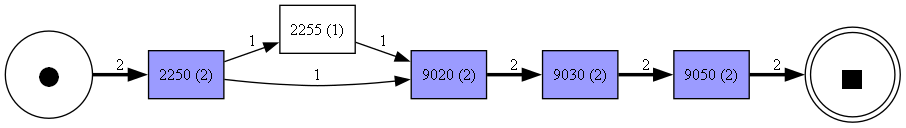

  Directed graph saved to ..\..\data\villach\heuristic_nets\PROCESS_CONTROL_DILABL_dfg.png


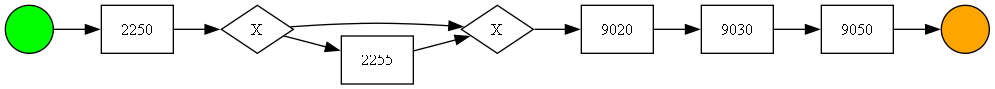

  BPMN saved to ..\..\data\villach\heuristic_nets\PROCESS_CONTROL_DILABL_bpmn.png

  PROCESS_CONTROL_DIZZZZ  (4 traces)


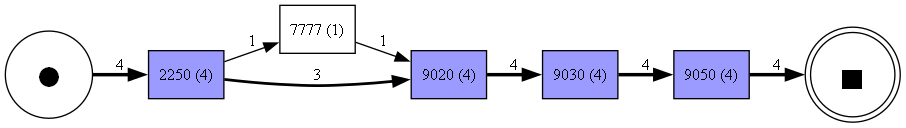

  Directed graph saved to ..\..\data\villach\heuristic_nets\PROCESS_CONTROL_DIZZZZ_dfg.png


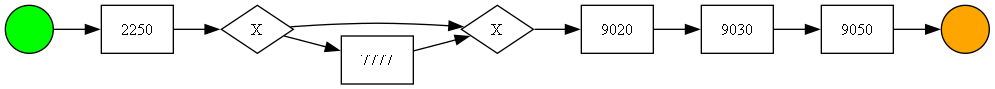

  BPMN saved to ..\..\data\villach\heuristic_nets\PROCESS_CONTROL_DIZZZZ_bpmn.png


In [4]:
for family, log in logs.items():
    print(f"\n{'='*60}")
    print(f"  {family}  ({len(log)} traces)")
    print(f"{'='*60}")

    dfg, start, end = pm4py.discover_dfg(log)
    pm4py.view_dfg(dfg, start, end)
    out_dfg = OUTPUT_DIR / f"{family}_dfg.png"
    pm4py.save_vis_dfg(dfg, start, end, str(out_dfg))
    print(f"  Directed graph saved to {out_dfg}")

    bpmn = pm4py.discover_bpmn_inductive(log)
    pm4py.view_bpmn(bpmn)
    out_bpmn = OUTPUT_DIR / f"{family}_bpmn.png"
    pm4py.save_vis_bpmn(bpmn, str(out_bpmn))
    print(f"  BPMN saved to {out_bpmn}")

## Summary

In [5]:
print(f"Generated {len(logs)} directed graphs and BPMN models:")
for family, log in logs.items():
    print(f"  {family}: {len(log)} traces")

Generated 6 directed graphs and BPMN models:
  LOGISTICS: 6 traces
  MOSFRA_DESFRA_DILABL: 2 traces
  MOSFRA_DESFRA_DIZZZZ: 2 traces
  MOWFRA_ERRZZZ_DIZZZZ: 2 traces
  PROCESS_CONTROL_DILABL: 2 traces
  PROCESS_CONTROL_DIZZZZ: 4 traces
